# Test partial marginalized posterior with DM!

In [1]:
import sys
sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')

import json
import pickle
import copy 
import random 
import glob

from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints

from jug.engine.session import TimingSession

from ATLAS.data import PTA_Data
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS import parameterized
from ATLAS.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel
from ATLAS.signals.timing.base import setup_timing_model
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils
from ATLAS import pulsar

# import MultiHMCGibbs

from ATLAS.samplers.canetoadracing import MultiHMCGibbs, MultiHMCGibbsWithAnalytic, AnalyticRhoTransition

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [3]:
from enterprise.pulsar import Pulsar

In [4]:
pnames = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

67

In [5]:
parfiles_ref = sorted(glob.glob('../data/NG15/partim/par/*.par'))
timfiles_ref = sorted(glob.glob('../data/NG15/partim/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [6]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [7]:
assert len(parfiles) == len(pnames)

In [9]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

67

In [10]:
def doit(pidx):
    return Pulsar(parfiles[pidx], timfiles[pidx], sort=True, ephem='DE440', timing_package='PINT')
with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
    psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))
    # psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(1))

with open('../data/NG15/NG15_v1p1_final_pint_psrs_sorted.pkl', 'wb') as fout:
    pickle.dump(psrs, fout)

PINT Loading...:   0%|          | 0/67 [00:00<?, ?it/s]

2026-06-30 14:38:51.897 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.925 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.927 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.937 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.941 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.964 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.964 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.971 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.972 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-06-30 14:38:51.972 | DEBUG    | pint.toa:get_TOAs:

In [11]:
with open('../data/NG15/NG15_v1p1_final_pint_psrs_sorted.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
psrs = [psr for psr in psrs if psr.name != 'J1713+0747'][:2]

In [12]:
with open('../data/NG15/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [13]:
chosen_pidx = 0 #np.argmin([len(psr.toas) for psr in psrs])
chosen_pidx 

0

In [14]:
psrs = psrs[chosen_pidx :chosen_pidx +1]

In [15]:
len(psrs)

1

In [16]:
psrs[0].name

'B1855+09'

In [17]:
timfiles[chosen_pidx :chosen_pidx +1]

['../data/NG15/partim/tim/B1855+09_PINT_20220301.nb.tim']

## Option 2: If you do not want to vary the timing model params, use the pre-made 15 year pulsar objects.

In [3]:
from enterprise.pulsar import FeatherPulsar
import glob

# feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
feather_files = glob.glob('../data/NG15/feathers/*.feather')
psrs = []
for feather_file in feather_files:
    psr = FeatherPulsar.read_feather(feather_file)
    psrs.append(psr)

# with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
#     noise_dict = json.load(fin)
with open('../data/NG15/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0610-2100.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers

In [4]:
psrs = psrs[0:3]

In [5]:
print(psrs)

[<Pulsar J1312+0051: 1705 res, 62 pars>, <Pulsar J0613-0200: 17124 res, 193 pars>, <Pulsar J0610-2100: 4885 res, 56 pars>]


In [6]:
data = PTA_Data(psrs, 
                fixed_res = False,
                marg_timing=False, 
                diag_white_cov=False,
                linear_timing = True,
                include_chromatic=True)

# Model Construction

## White Noise Model

In [7]:
wn_model = WhiteCov(data = data)

  0%|          | 0/3 [00:00<?, ?it/s]

## Timing Model

In [8]:
raw_res = jnp.concat(data.raw_residuals)

### Initial white noise guess

In [9]:
theta0_wn = wn_model.prior_draw()
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.04982172,  0.96948031, -6.17884779, -5.56093065, -7.03963453],      dtype=float64)

## Red Noise Model

In [10]:
non_gwb_nfreqs = 30

### Non-GWB Model

#### Choose your PSD model

In [11]:
# Example:
# chosen_psd_model_nongwb, helper_dictionary_nongwb = unc_utils.varied_gamma_pl(renorm_const = 1)
chosen_psd_model_nongwb, helper_dictionary_nongwb = unc_utils.spectrum(renorm_const = 1, crn_bins = non_gwb_nfreqs)

In [12]:
sig_unc = Red(name='unc', 
                nfreqs=non_gwb_nfreqs, 
                halflog10_rho_range=(-9,-2),
                data = data,
                use_pulsar_tspan = False)

In [13]:
sig_chr = Red(name='chr', 
                nfreqs=non_gwb_nfreqs, 
                halflog10_rho_range=(-9,-2),
                data = data,
                use_pulsar_tspan = False)

### GWB Model

#### Choose your PSD model

In [14]:
gwb_nfreqs = 14

In [15]:
chosen_psd_model, chosen_orf_model, gwb_helper_dictionary = cor_utils.fixed_gamma_hd_pl(renorm_const = 1)

In [16]:
sig_cor = Correlated(name='cor', 
                    nfreqs=gwb_nfreqs, 
                    halflog10_rho_range=(-9,-2),
                    data = data)

### The user should not see this in the final version, but for now you need to see this!

In [ ]:
# signal_helper = {
#     'shared_basis': { #shared basis does not mean the nfreqs are the same between signals.
#                     #It means that one basis includes the other one.
#     'signal_list': [sig_cor], 
#     'index_of_signal_used_for_basis': 0,
#     },

#     'separate': {
#         'signal_list': [sig_unc, sig_chr]
#         },
#     'order': 'cor,unc,chr',
#     }

In [26]:
signal_helper = {
    'shared_basis': { #shared basis does not mean the nfreqs are the same between signals.
                    #It means that one basis includes the other one.
    'signal_list': [sig_cor], 
    'index_of_signal_used_for_basis': 0,
    },

    'separate': {
        'signal_list': [sig_chr]
        },
    'order': 'cor,chr',
    }

### `sig.get_helpers` updates the white noise covaraince matrix

In [27]:
sig = SuperSignal(signal_helper = signal_helper, 
                data=data,
)

In [28]:
Fconcat = sig.get_Fmat_concat

In [29]:
M_FG = Fconcat[:, :sig.linear_timing_model_size + sig_cor.nmodes]
F_irn_F_dm = Fconcat[:, sig.linear_timing_model_size + sig_cor.nmodes:]

In [51]:
wn_params = wn_model.params_dict_to_vector(noise_dict)

In [53]:
helpers = wn_model.get_red_det_helpers(M_FG, F_irn_F_dm, raw_res, wn_params)
TNT, TNr, rNr, logdet_N, TpNTp, TpNr, TNTp = helpers

In [54]:
for helper in helpers:
    print(helper.shape)

(3, 221, 221)
(3, 221)
()
()
(3, 60, 60)
(3, 60)
(3, 221, 60)


In [55]:
ll, ul = wn_model.get_prior_bounds() #white noise prior bounds
ll[:5], ul[:5]

(Array([ 0.01,  0.01, -9.  , -9.  , -9.  ], dtype=float64),
 Array([10., 10., -5., -5., -5.], dtype=float64))

In [56]:
sig_unc.tspans/(86400 * 365.25)

15.351390925823674

In [57]:
gwb_Tspan = data.pta_tspan
gwb_Tspan/(365.25 * 86400)

15.351390925823674

In [58]:
o = parameterized.MultiPulsarRedNoise(
            # ---- GWB ----
            gwb_psd_func = chosen_psd_model,
            orf_func = chosen_orf_model,
            crn_bins = gwb_nfreqs,
            # irn_bins = non_gwb_nfreqs,
            f_common = sig_cor.freqs, 
            # f_irn = sig_unc.freqs,
            Npulsars = sig.npsrs,
            psr_pos = data.psr_pos,
            gwb_helper_dictionary = gwb_helper_dictionary,
            renorm_const = 1,

            #----- indices of Gaussian processes ------
            first_crn_bin_index=0,
            # first_irn_bin_index=gwb_nfreqs,
            # first_dm_bin_index=gwb_nfreqs+non_gwb_nfreqs
            first_dm_bin_index=gwb_nfreqs,

            # ---- non-GWB intrinsic red noise (optional) ----
            # irn_psd_func=chosen_psd_model_nongwb,
            # irn_helper_dictionary=helper_dictionary_nongwb,

            # different bases
            shared_irn_and_gwb=False,

            dm_psd_func=chosen_psd_model_nongwb,
            dm_helper_dictionary=helper_dictionary_nongwb,
            f_dm = sig_chr.freqs,
            dm_bins = len(sig_chr.freqs)
            )
sig.add_parameterization(o)

In [59]:
x0 = o.make_initial_guess(jrandom.key(1273442)) #red noise model params
phi0 = o.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

AttributeError: 'MultiPulsarRedNoise' object has no attribute 'irn_bins'

# Likelihood

### Reparameterized likelihood

In [60]:
z0 = jrandom.normal(jrandom.key(10098), shape = (sig.npsrs, sig.linear_timing_model_size + sig_cor.nmodes)) # re-parameterized coefficients

In [61]:
z0.shape

(3, 221)

In [62]:
x0.shape

(91,)

In [63]:
full_gwb_phi, gwb_phi_diag, psr_phi_diags = sig.model.partial_reparm_helper(x0)

In [64]:
psr_phi_diags.shape

(30, 3)

In [65]:
full_gwb_phi.shape

(14, 3, 3)

In [66]:
gwb_phi_diag.shape

(14, 1)

In [67]:
lnprob0, coeff0 = sig.lnposterior_partial_marg_reparam(helpers = helpers, 
                                               red_params = x0,
                                               z = z0)
lnprob0

Array(24933.34777291, dtype=float64)

In [68]:
%timeit sig.lnposterior_partial_marg_reparam(helpers = helpers,  red_params = x0,z = z0)

2.08 ms ± 6.13 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [69]:
def model():

    z = numpyro.sample('z_red', dist.Normal().expand(z0.shape))

    rn_params = numpyro.sample('rn_params', dist.Uniform(o.lower_prior_lim_all, o.upper_prior_lim_all))

    # helpers_new = sig.get_helpers

    lnpost_val, a = sig.lnposterior_partial_marg_reparam(helpers=helpers,
                                            red_params=rn_params,
                                            z=z)

    # numpyro.deterministic('a', a)
    numpyro.factor('lnpost', lnpost_val + 0.5 * jnp.sum(z**2))

In [70]:
nuts_kernel = numpyro.infer.NUTS(model=model)
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=500,
                          num_samples=1000,
                          num_chains=1)
mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

sample: 100%|██████████| 1500/1500 [02:30<00:00,  9.98it/s, 7 steps of size 3.66e-05. acc. prob=0.86]  


In [72]:
samples['rn_params']

Array([[ -6.70765334,  -8.09739729,  -5.40323577, ...,  -8.97422983,
         -8.8202532 , -18.        ],
       [ -6.70765062,  -8.09739726,  -5.40323328, ...,  -8.97422981,
         -8.82025299, -18.        ],
       [ -6.70765127,  -8.09739793,  -5.40323712, ...,  -8.97422985,
         -8.82025291, -18.        ],
       ...,
       [ -6.70765097,  -8.09744117,  -5.40313457, ...,  -8.97422972,
         -8.8202488 , -18.        ],
       [ -6.7076511 ,  -8.09744152,  -5.40313498, ...,  -8.97422971,
         -8.8202488 , -18.        ],
       [ -6.7076512 ,  -8.09744181,  -5.40313508, ...,  -8.97422973,
         -8.82024899, -18.        ]], dtype=float64)

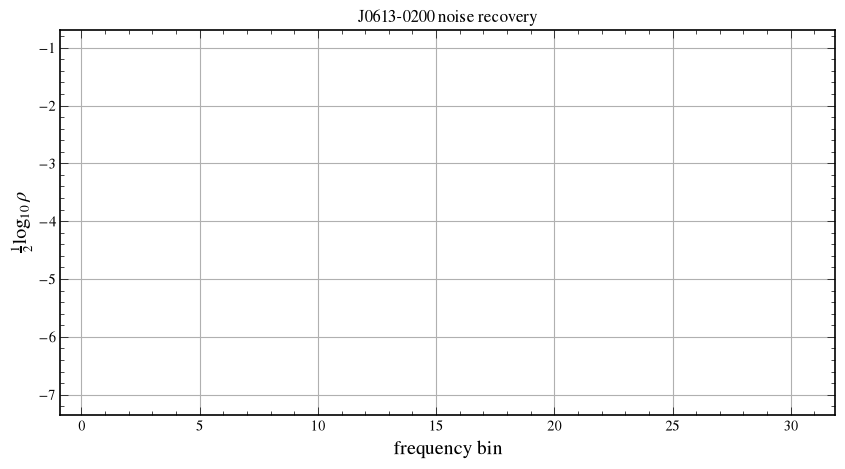

In [71]:
psr_ndx = 1
plt.figure(figsize=(10, 5))
plt.violinplot(dataset=np.array(samples['rn_params'])[:, psr_ndx * non_gwb_nfreqs : (psr_ndx + 1) * non_gwb_nfreqs],
               widths=0.8,
               showextrema=False)
plt.xlabel('frequency bin', fontsize=14)
plt.ylabel(r'$\frac{1}{2}\log_{10}\rho$', fontsize=14)
plt.title(f'{data.psr_names[psr_ndx]} noise recovery')
plt.grid()
plt.show()

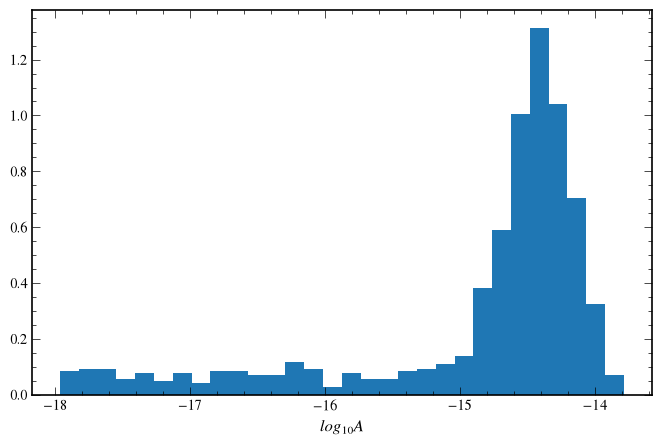

In [67]:
plt.figure(figsize=(8, 5))
plt.hist(samples['rn_params'][:, -1], density=True, bins=30)
plt.xlabel(r'$log_{10}A$')
plt.show()

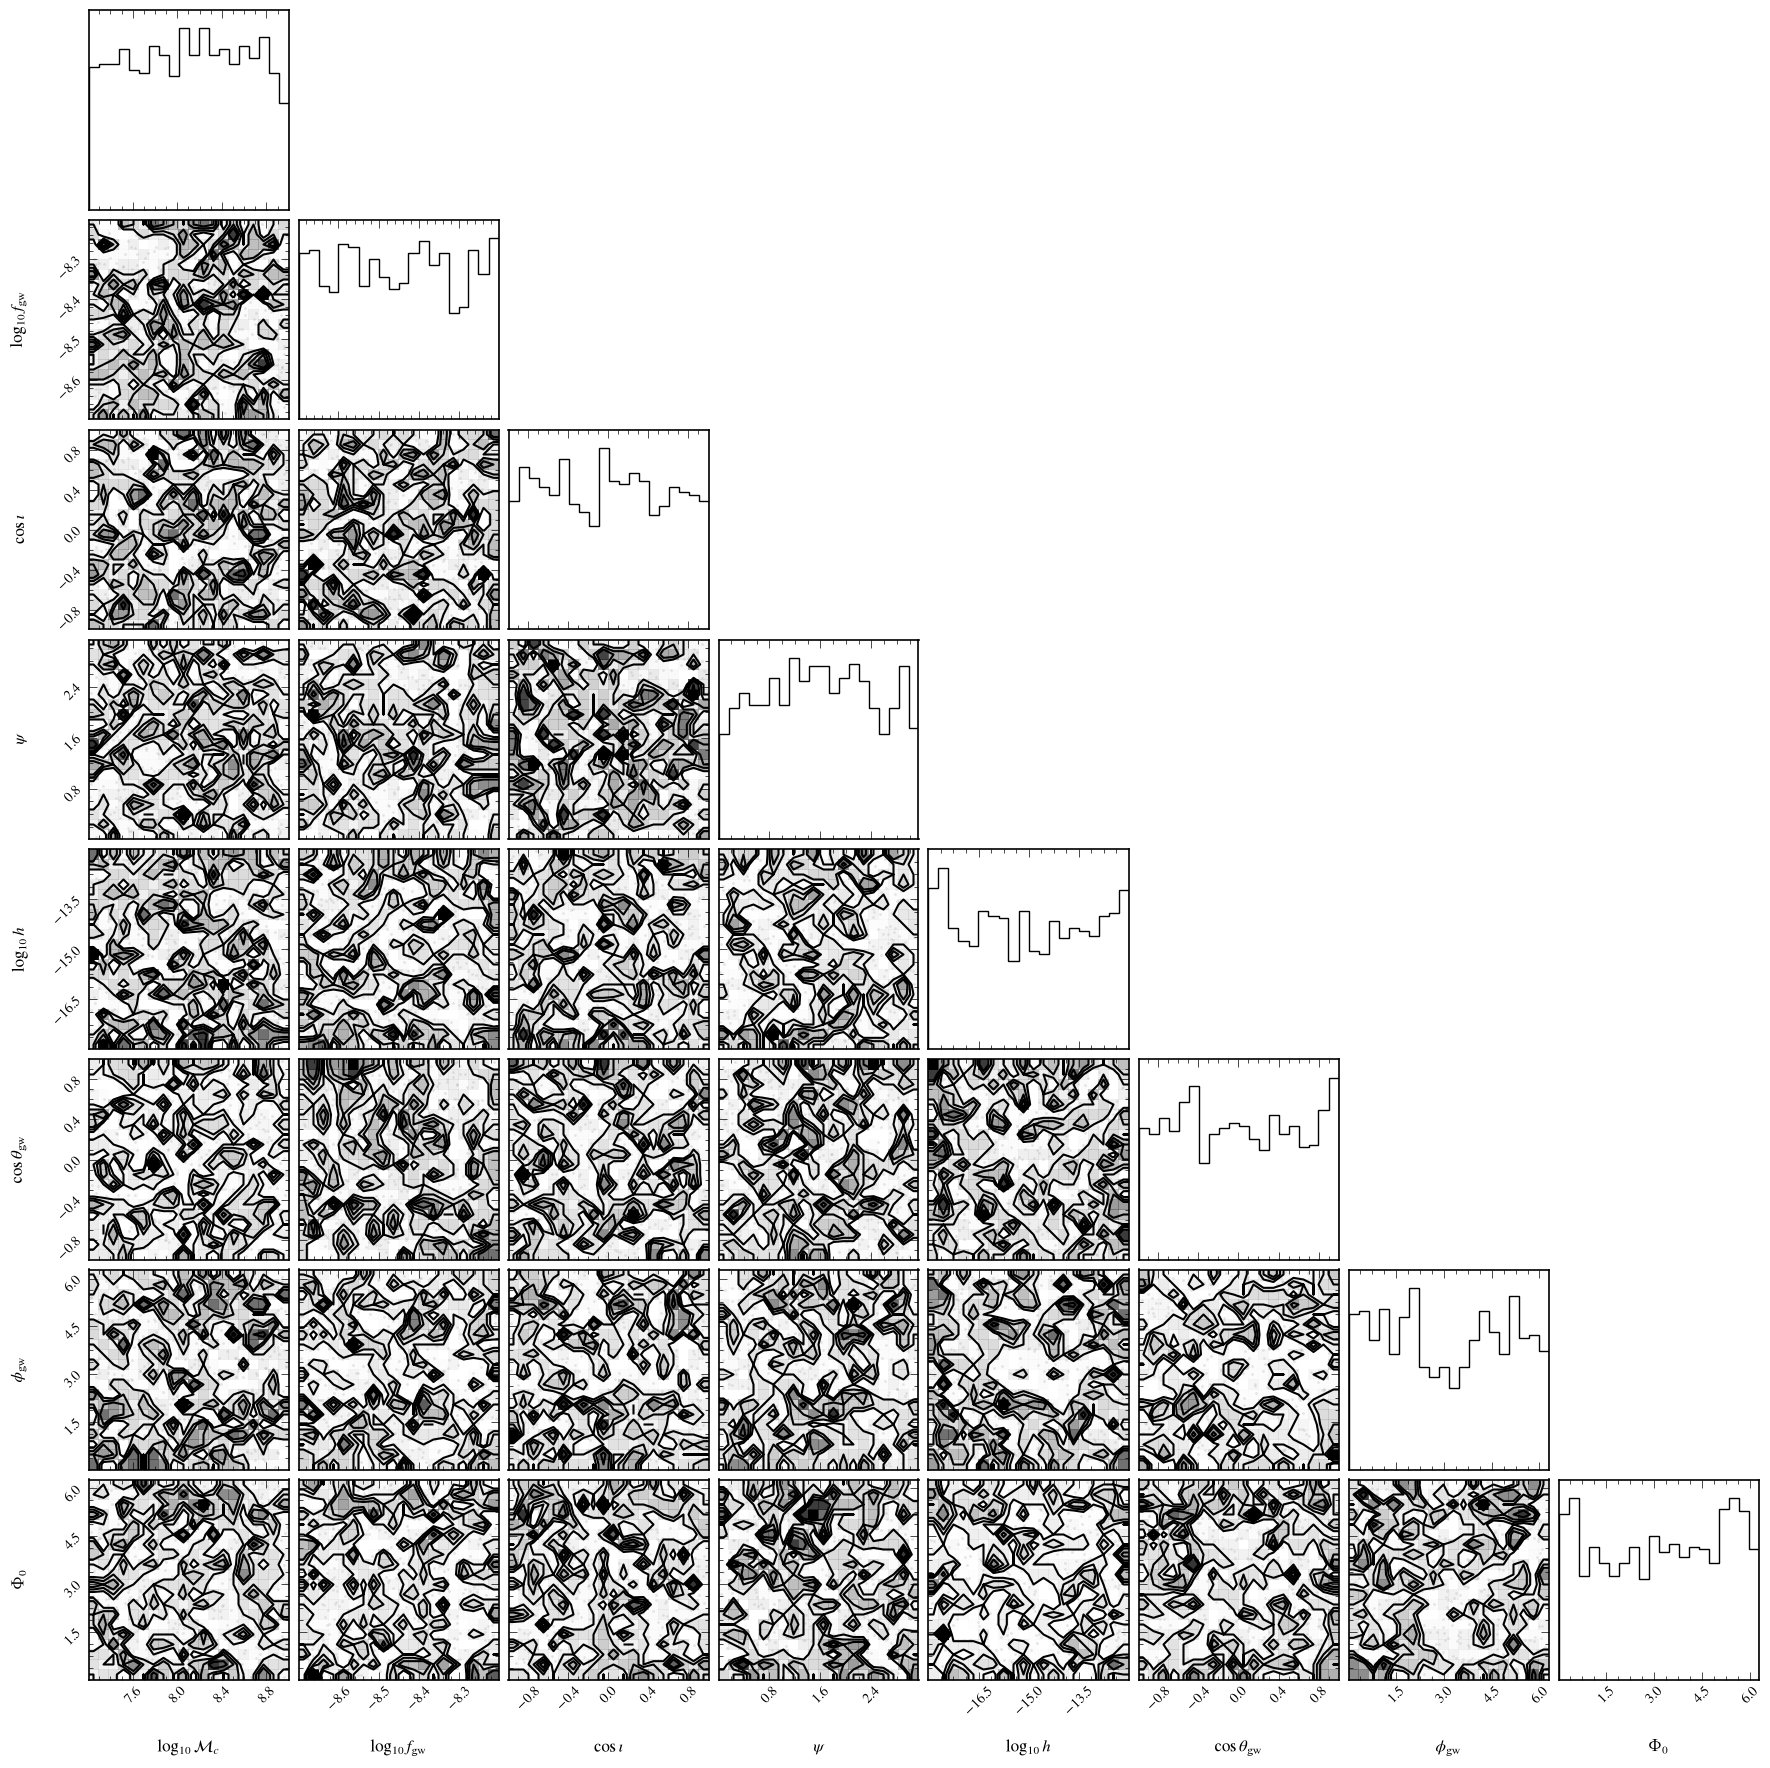

In [70]:
import corner
cw_param_labels = [
    r"$\log_{10}\mathcal{M}_c$",
    r"$\log_{10}f_\mathrm{gw}$",
    r"$\cos\iota$",
    r"$\psi$",
    r"$\log_{10}h$",
    r"$\cos\theta_\mathrm{gw}$",
    r"$\phi_\mathrm{gw}$",
    r"$\Phi_0$",
]

fig = corner.corner(data=np.array(samples['cw_params']),
                    labels=cw_param_labels,
                    label_kwargs={'fontsize': 12})